# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

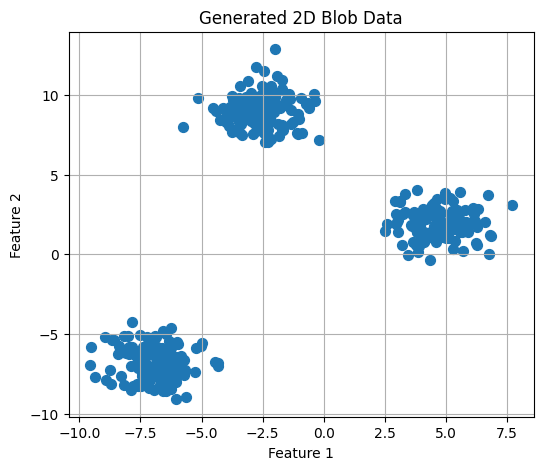

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


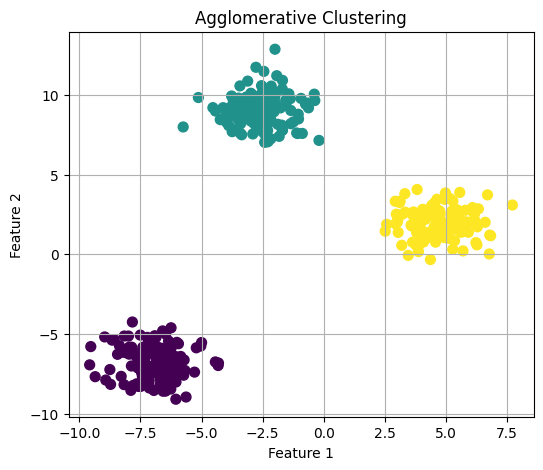

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

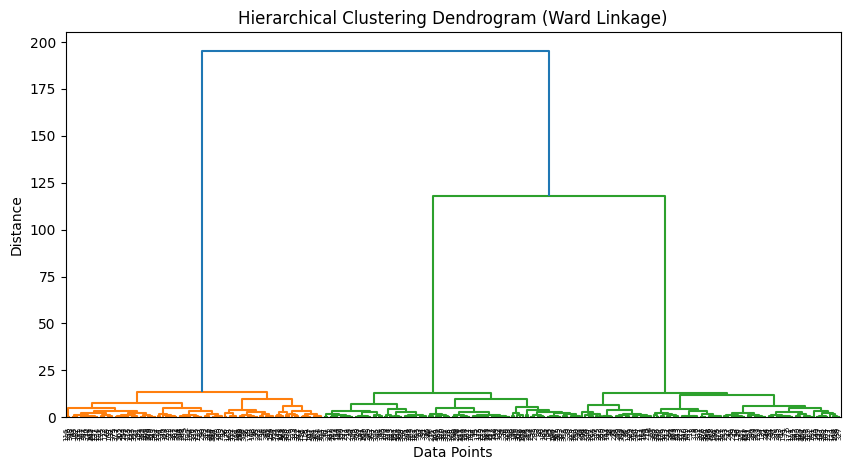

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('CC GENERAL.csv')
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)

Shape: (8950, 18)

Data Types:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [3]:
print('Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [4]:
print('Summary Statistics:')
display(df.describe().T.round(2))

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.0,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.0,1003.20,2136.63,0.00,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.0,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.0,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.0,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.0,0.14,0.20,0.00,0.00,0.00,0.22,1.50


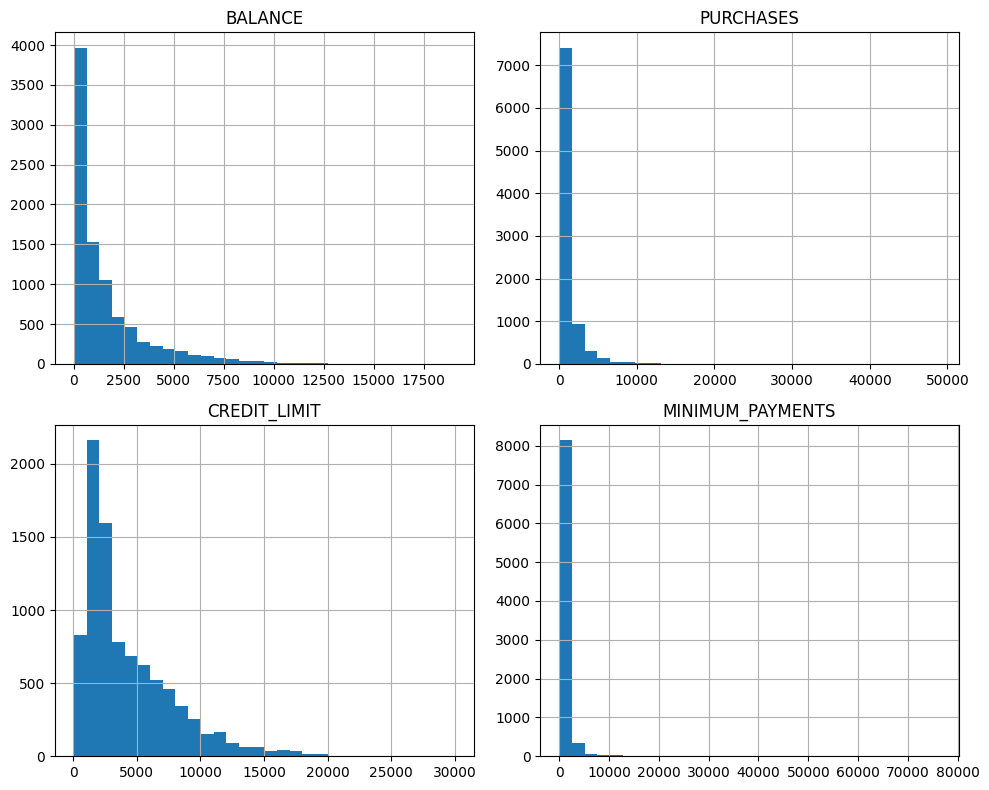

In [5]:
df[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

## **2. Data Preparation**

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

df_prep = df.drop(columns=['CUST_ID']).copy()

In [ ]:
median_credit = df_prep['CREDIT_LIMIT'].median()
median_min_pay = df_prep['MINIMUM_PAYMENTS'].median()

df_prep['CREDIT_LIMIT'] = df_prep['CREDIT_LIMIT'].fillna(median_credit)
df_prep['MINIMUM_PAYMENTS'] = df_prep['MINIMUM_PAYMENTS'].fillna(median_min_pay)

print('Missing left:', df_prep.isnull().sum().sum())

Missing left: 0


In [ ]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_prep)

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Original features: {X_scaled.shape[1]}')
print(f'PCA features keeping 95% variance: {pca.n_components_}')

Original features: 17
PCA features keeping 95% variance: 9


## **3. Apply Agglomerative Clustering**

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_pca, method='ward', metric='euclidean')

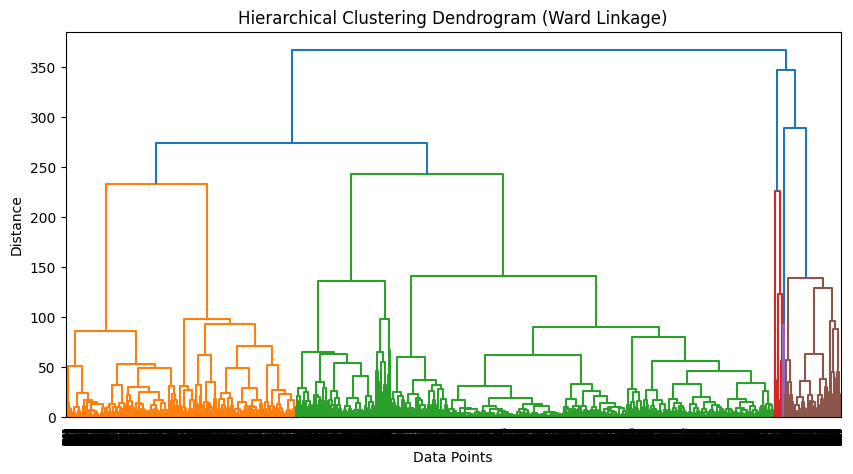

In [ ]:
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

k = 5
agg_cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
cluster_labels = agg_cluster.fit_predict(X_pca)

In [15]:
print('Cluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
print(dict(zip(unique, counts)))

Cluster sizes:
{np.int64(0): np.int64(5528), np.int64(1): np.int64(2660), np.int64(2): np.int64(98), np.int64(3): np.int64(23), np.int64(4): np.int64(641)}


## **4. Visualize the Clustering Results**

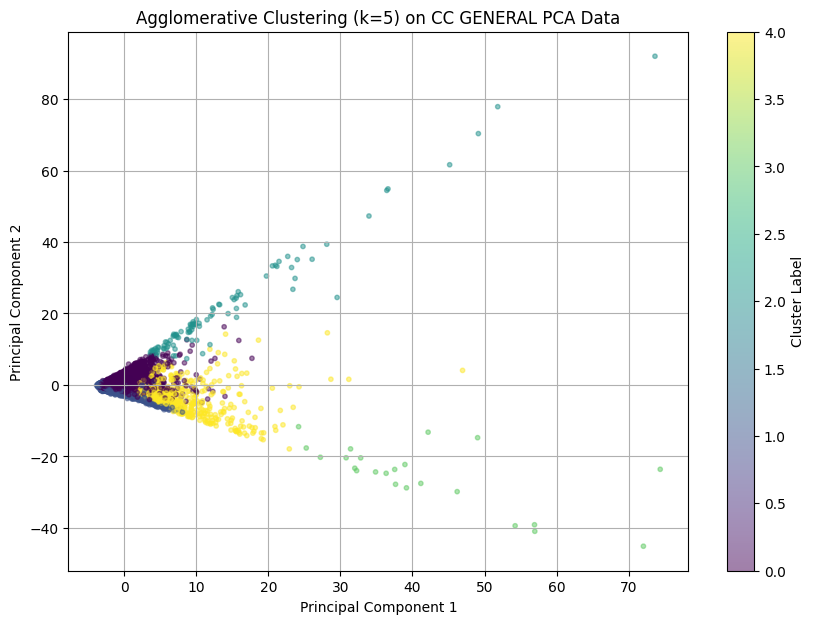

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=10, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Agglomerative Clustering (k={k}) on CC GENERAL PCA Data')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

In [ ]:
df_clustered = df_prep.copy()
df_clustered['Cluster'] = cluster_labels

cluster_profile = df_clustered.groupby('Cluster').mean().round(2)
print('Cluster Profiles (mean of original features):')
display(cluster_profile)

Cluster Profiles (mean of original features):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2002.66,0.97,514.38,290.03,224.57,1388.95,0.40,0.15,0.29,0.19,4.72,8.94,4200.71,1563.01,800.05,0.03,11.44
1,162.28,0.65,846.35,430.65,416.00,235.23,0.57,0.20,0.43,0.03,0.59,13.08,4197.87,1254.25,184.69,0.42,11.57
2,3149.00,0.99,667.28,146.98,520.30,1015.91,0.46,0.05,0.42,0.11,3.29,15.09,3347.45,1228.23,16767.03,0.00,11.81
3,4812.38,0.96,27505.34,22417.45,5087.89,1617.79,0.91,0.85,0.71,0.06,2.61,124.13,16000.00,28138.98,2599.09,0.53,11.91
4,3245.54,0.99,4970.21,3156.75,1814.47,499.71,0.92,0.65,0.74,0.07,1.58,67.24,8018.56,4317.38,1474.25,0.12,11.95


## **5. Evaluate the Clustering**

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, cluster_labels)
print(f'Silhouette Score (k={k}): {score:.4f}')

Silhouette Score (k=5): 0.2367


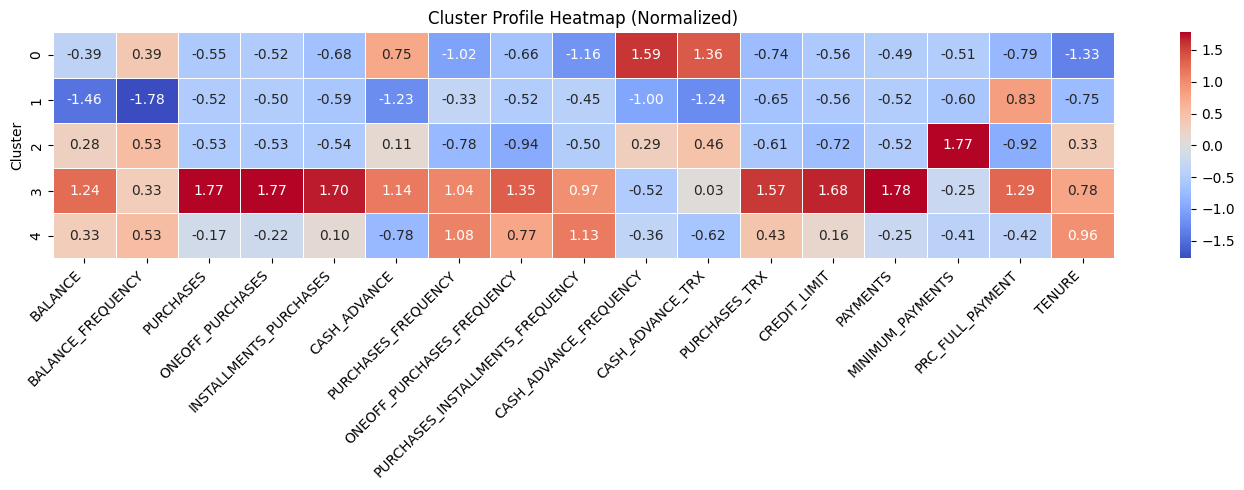

In [ ]:
import seaborn as sns

profile_normalized = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

plt.figure(figsize=(14, 5))
sns.heatmap(profile_normalized, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Profile Heatmap (Normalized)')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **6. Explain whether the clustering quality and justify your reasoning**

By using RobustScaler and imputing with the median, I mitigated the extreme outliers associated with credit card purchases and balances. Applying PCA isolated the most important structural variances and reduced the dimensionality from 17 down to a smaller number of dense components.

The Silhouette Score of 0.2367 indicates weak cluster separation, which is expected with real-world financial data where customer behaviour overlaps rather than forming distinct groups. The cluster profiles are more informative than the score alone.

The cluster profile heatmap provides behavioral interpretation of each segment. For example, clusters with high PURCHASES and low BALANCE represent active transactors who pay off regularly, while clusters with high BALANCE and high CREDIT_LIMIT but low PURCHASES suggest revolvers who carry debt. This segmentation is directly useful for targeted marketing or credit risk strategies.